In [142]:
import numpy as np
from typing import List, Tuple
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

## Phần 1: Xây dựng mô hình hồi quy đơn biến
1. Khám phá mối liên hệ giữa chỉ số đường huyết (fbs) và bệnh tim. Tạo bảng chéo hai chiều và tóm tắt mối quan hệ.
2. Khám phá mối liên hệ giữa tuổi và bệnh tim. Tạo biểu đồ hoặc thống kê mô tả phù hợp.
3. Huấn luyện mô hình hồi quy Logistic chỉ với biến fbs (chỉ số đường huyết). Trình bày kết quả mô hình và giải thích các hệ số.
4. Viết biểu thức mô hình dựa trên các hệ số ước lượng.
5. Diễn giải ý nghĩa của e^(beta_0) trong ngữ cảnh mô hình.
6. Diễn giải ý nghĩa của e^(beta_1) (biến fbs) trong ngữ cảnh mô hình
7. Tính xác suất dự đoán mắc bệnh tim
    - Bệnh nhân có fbs = 0 (bình thường).
    - Bệnh nhân có fbs = 1 (cao).

Bảng chéo giữa chỉ số đường huyết (fbs) và bệnh tim
target    0    1  All
fbs                  
0       114  100  214
1        17   17   34
All     131  117  248


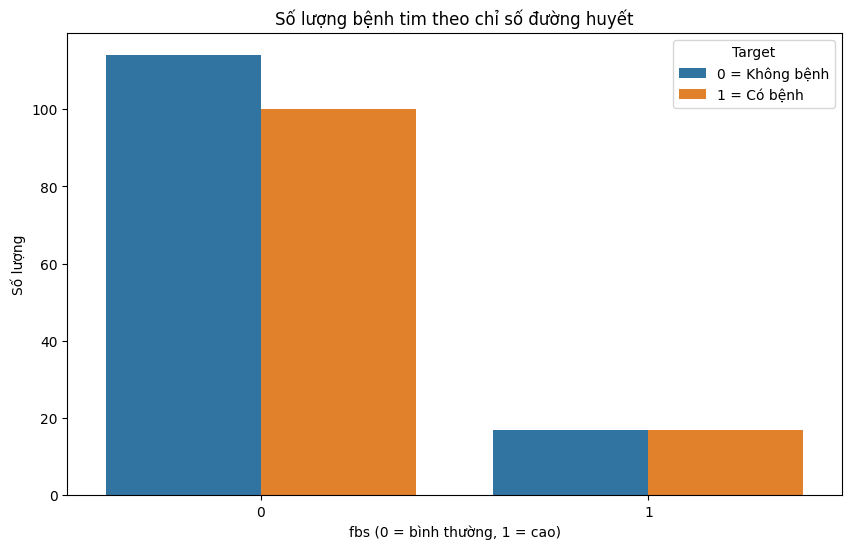

In [143]:
df = pd.read_csv("train.csv") # Câu lệnh này sẽ thực hiện từ câu hỏi bài tập 1 đến 7
# Bài 1
# Khám phá mối liên hệ giữa chỉ số đường huyết (fbs) và bệnh tim. Tạo bảng chéo hai chiều và tóm tắt mối quan hệ
crosstab_fbs = pd.crosstab(df['fbs'], df['target'], margins=True)
print("Bảng chéo giữa chỉ số đường huyết (fbs) và bệnh tim")
print(crosstab_fbs)

plt.figure(figsize=(10, 6))
sns.countplot(x='fbs', hue='target', data=df)
plt.title("Số lượng bệnh tim theo chỉ số đường huyết")
plt.xlabel("fbs (0 = bình thường, 1 = cao)")
plt.ylabel("Số lượng")
plt.legend(title='Target', labels=['0 = Không bệnh', '1 = Có bệnh'])
plt.show()

Thống kê mô tả biến tuổi theo nhóm Target
        count   mean   std   min   25%   50%   75%   max
target                                                  
0       131.0  52.31  9.64  29.0  44.5  52.0  59.0  76.0
1       117.0  56.68  8.01  35.0  52.0  58.0  62.0  77.0


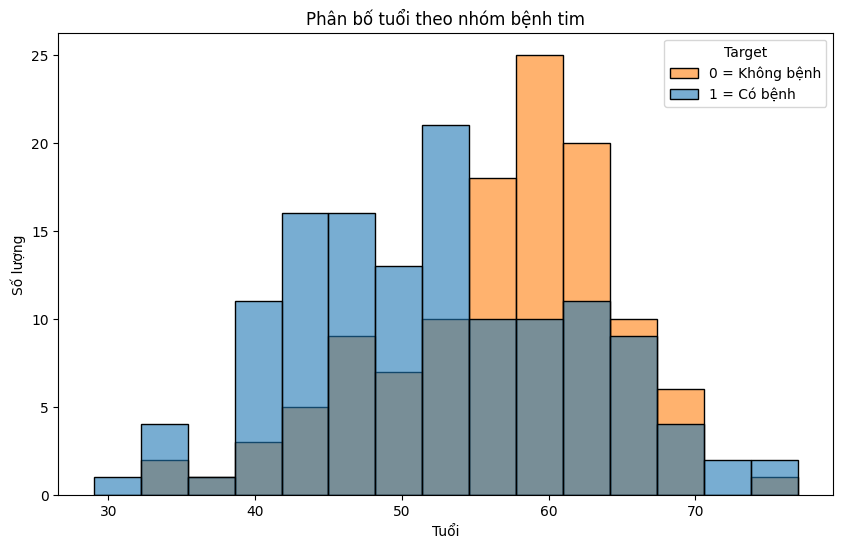

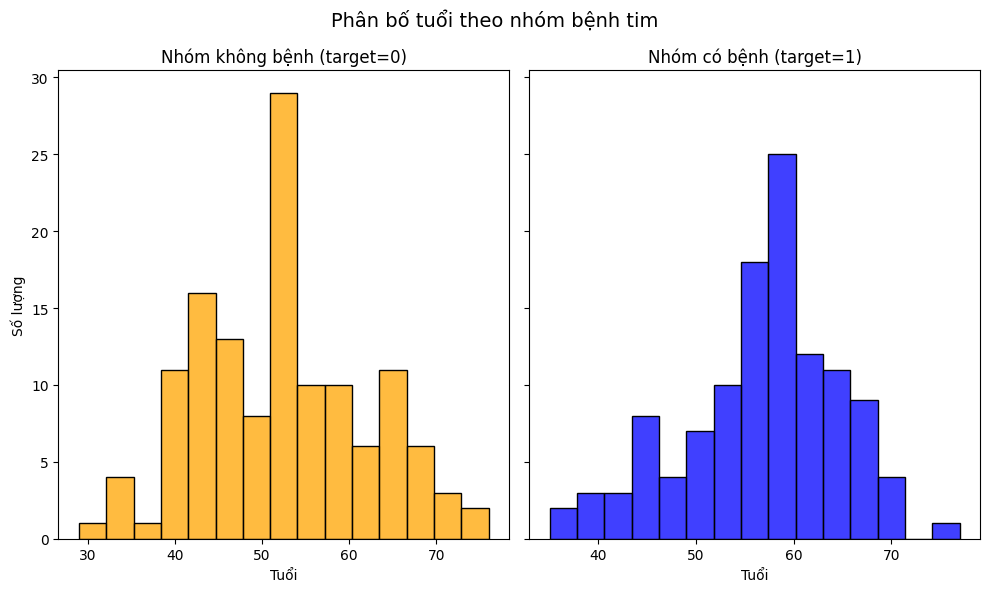

In [144]:
# Bài 2
# Khám phá mối liên hệ giữa tuổi và bệnh tim. Tạo biểu đồ hoặc thống kê mô tả phù hợp
grouped = df.groupby('target')
age_stats = grouped['age'].describe()
age_stats = age_stats.round(2)
print("Thống kê mô tả biến tuổi theo nhóm Target")
print(age_stats)

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='target', bins=15, kde=False, alpha=0.6)
plt.title("Phân bố tuổi theo nhóm bệnh tim")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng")
plt.legend(title='Target', labels=['0 = Không bệnh', '1 = Có bệnh'])
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Histogram cho nhóm không bệnh (target=0)
sns.histplot(data=df[df['target'] == 0], x='age', bins=15, kde=False, color='orange', ax=axes[0])
axes[0].set_title("Nhóm không bệnh (target=0)")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("Số lượng")

# Histogram cho nhóm có bệnh (target=1)
sns.histplot(data=df[df['target'] == 1], x='age', bins=15, kde=False, color='blue', ax=axes[1])
axes[1].set_title("Nhóm có bệnh (target=1)")
axes[1].set_xlabel("Tuổi")
axes[1].set_ylabel("Số lượng")

plt.suptitle("Phân bố tuổi theo nhóm bệnh tim", fontsize=14)
plt.tight_layout()
plt.show()

In [145]:
# Bài 3: Huấn luyện mô hình hồi quy logistic chỉ với biến fbs. Trình bày kết quả mô hình và giải thích các hệ số.
# Lớp này sẽ sử dụng cho mô hình đơn biến và đa biến
# Sinh viên đã tự xây dựng mô hình hồi quy Logistic dựa trên lý thuyết và nguồn youtube dưới đây để thiết kế thành lớp
# https://www.youtube.com/watch?v=S6iuhdYsGC8
# Lý thuyết sinh viên đã dùng để làm theo
# https://github.com/JuzerShakir/Logistic_Regression/blob/master/README.md
from scipy.stats import norm
class LogisticRegression:
    def __init__(self, alpha=0.1, num_iter=100, tol=1e-5, scale=False):
        # Khai báo tham số cơ bản
        self.alpha = alpha # learning rate
        self.num_iter = num_iter # giới hạn số lần lặp
        self.tol = tol # Sai số chấp nhận được
        
        # Lưu lại mấy hệ số cần thiết
        self.theta = None # Hệ số 
        self.X_b = None # Bias
        self.y = None # target
        
        # Mode scale theo z-score
        self.scale = scale # flag để yêu cầu scale số liệu lại (False là dùng dữ liệu gốc, True là chuẩn hóa các thuộc tính theo z-scores)
        self.mean_ = None
        self.std_ = None
        
    def sigmoid(self, z):
        # Trong trường hợp số quá lớn ở dương hay quá nhỏ ở âm thì sẽ thu hẹp lại nhằm tránh overflow
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))
    
    def calculate_gradient(self, theta, X_b, y):
        m = y.size
        return (X_b.T @ (self.sigmoid(X_b @ theta) - y)) / m
    
    def _scale_X(self, X):
        if not self.scale: # Trả về giá trị gốc nếu không bật mode scale
            return X
        return (X - self.mean_) / self.std_
    
    def fit(self, X, y):
        """Khớp tập dữ liệu bằng phương pháp Gradient Descent đã được đề cập từ đồ án số 2"""
        # Nếu là true, scale các thuộc tính lại
        if self.scale:
            self.mean_ = X.mean(axis=0)
            self.std_ = X.std(axis=0, ddof=0)
            self.std_[self.std_ == 0] = 1.0
            X = self._scale_X(X)
        
        self.X_b = np.c_[np.ones((X.shape[0], 1)), X]
        self.y = y
        self.theta = np.zeros(self.X_b.shape[1])
        
        for i in range(self.num_iter):
            grad = self.calculate_gradient(self.theta, self.X_b, y)
            self.theta -= self.alpha * grad
            
            if np.linalg.norm(grad) < self.tol:
                # Cho biết đã hội tụ về
                print(f"Hội tụ sau {i+1} vòng lặp")
                break
    
    # Dự đoán xác suất sẽ mang giá trị bao nhiêu
    def predict_proba(self, X):
        X = self._scale_X(X)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return self.sigmoid(X_b @ self.theta)
    
    # Từ giá trị sản xuất đó, với ngưỡng mặc định là 0.5, đánh nhãn mẫu thử đó là 0 hoặc 1 (ở bài này 0 là không có bệnh, 1 là có bệnh)
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def loss(self, X, y):
        X = self._scale_X(X)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        p = self.sigmoid(X_b @ self.theta)
        return -np.mean(y * np.log(p + 1e-8) + (1 - y) * np.log(1 - p + 1e-8))

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
    # Phương thức/hàm này có nhiệm vụ cho câu hỏi bài tập số 9 (sinh viên tự xây dựng không sử dụng thư viện stats model vì stats sử dụng mô hình khác với mô hình sinh viên thực hiện)
    def summary(self, feature_names=None):
        # Xác suất dự đoán
        p = self.sigmoid(self.X_b @ self.theta)
        W = np.diag(p * (1 - p))

        # Ma trận hiệp phương sai
        XtWX_inv = np.linalg.inv(self.X_b.T @ W @ self.X_b)
        # Standard error
        se = np.sqrt(np.diag(XtWX_inv))

        # Z-scores
        z_scores = self.theta / se

        # p-values
        p_values = 2 * (1 - norm.cdf(np.abs(z_scores)))

        if feature_names is None:
            feature_names = [f"x{i}" for i in range(1, len(self.theta))]
        feature_names = ["Intercept"] + feature_names

        results = pd.DataFrame({
            "Feature": feature_names,
            "Coef": self.theta,
            "StdErr": se,
            "z": z_scores,
            "p-value": p_values
        })
        return results
    

In [ ]:
# Chuẩn bị dữ liệu
X = df[['fbs']].values
y = df['target'].values

# Chia 80% của train.csv để train mô hình, 20% còn lại để valid
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Huấn luyện Logistic Regression với mô hình đơn biến (fbs)
model_uni = LogisticRegression(alpha=0.01, num_iter=30000, tol=1e-5, scale=False)
model_uni.fit(X_train, y_train)

# Nếu chỉ sử dụng 1 biến thì với learning rate như tham số trên thì có thể hội tụ dễ dàng được, có thể dùng scale hoặc không scale đều được
# Nếu không scale thì cũng không sao vì fbs chỉ có 2 giá trị là bình thường (0) và Cao (1).

beta_0, beta_1 = model_uni.theta
print(f"Hệ số beta0: {beta_0: .4f}")
print(f"Hệ số beta1: {beta_1: .4f}")
# Câu 4
print(f"Mô hình: p(y=1|fbs) = 1 / (1 + exp(-({beta_0:.4f} + {beta_1:.4f}*fbs)))")


Hội tụ sau 19974 vòng lặp
Hệ số beta0: -0.1430
Hệ số beta1:  0.1428
Mô hình: p(y=1|fbs) = 1 / (1 + exp(-(-0.1430 + 0.1428*fbs)))


In [155]:
# Câu 7
p_fbs0 = model_uni.predict_proba(np.array([[0]]))[0]
p_fbs1 = model_uni.predict_proba(np.array([[1]]))[0]

print(f"Xác suất mắc bệnh tim nếu fbs=0: {p_fbs0: .4f}")
print(f"Xác suất mắc bệnh tim nếu fbs=1: {p_fbs1: .4f}")

Xác suất mắc bệnh tim nếu fbs=0:  0.4643
Xác suất mắc bệnh tim nếu fbs=1:  0.4999


In [ ]:
train_pred_prob = model_uni.predict_proba(X_train)
train_pred_class = model_uni.predict(X_train)

df_train = pd.DataFrame({
    "fbs": X_train.ravel(),
    "target": y_train,
    "Pred_Prob": train_pred_prob,
    "Pred_Class": train_pred_class
})

print("=== Dự đoán trên tập TRAIN ===")
print(df_train.to_string())

train_acc_full = (df_train["Pred_Class"] == df_train["target"]).mean()
print(f"Accuracy TRAIN: {train_acc_full:.4f}\n")

In [159]:
val_pred_prob = model_uni.predict_proba(X_val)
val_pred_class = model_uni.predict(X_val)

df_valid = pd.DataFrame({
    "fbs": X_val.ravel(),
    "target": y_val,
    "Pred_Prob": val_pred_prob,
    "Pred_Class": val_pred_class
})

print("=== Dự đoán trên tập VALID ===")
print(df_valid.to_string())

val_acc_full = (df_valid["Pred_Class"] == df_valid["target"]).mean()
print(f"Accuracy TRAIN: {val_acc_full:.4f}\n")

=== Dự đoán trên tập VALID ===
    fbs  target  Pred_Prob  Pred_Class
0     0       1   0.464299           0
1     0       0   0.464299           0
2     0       0   0.464299           0
3     0       0   0.464299           0
4     0       0   0.464299           0
5     0       1   0.464299           0
6     0       1   0.464299           0
7     0       0   0.464299           0
8     0       1   0.464299           0
9     0       0   0.464299           0
10    0       0   0.464299           0
11    0       0   0.464299           0
12    0       1   0.464299           0
13    0       0   0.464299           0
14    0       1   0.464299           0
15    0       0   0.464299           0
16    0       0   0.464299           0
17    0       1   0.464299           0
18    0       0   0.464299           0
19    0       0   0.464299           0
20    0       1   0.464299           0
21    0       1   0.464299           0
22    1       1   0.499935           0
23    0       0   0.464299       

In [ ]:
# Kiểm tra dự đoán của mô hình đơn biến với biến fbs với xác suất được tính như trên thì dựa vào tập train thì
# trả về kết quả dự đoán như hiển thị console dưới đây
# Dựa trên tập dữ liệu train.csv, đối chiếu xem là mô hình với dữ liệu gốc dự đoán như thế nào, chính xác bao nhiêu và đưa ra nhận xét
# dựa trên mô hình mình đang xây dựng
# df['Pred_Prob'] = model_uni.predict_proba(df[['fbs']].values)
# df['Pred_Class'] = model_uni.predict(df[['fbs']].values)

# print(df[['fbs', 'target', 'Pred_Prob', 'Pred_Class']].to_string())

# accuracy = (df['Pred_Class'] == df['target']).mean()
# print(f"Accuracy trên train.csv: {accuracy:.4f}")

# Code trên này sai vì dám cho model học hết train.csv

In [162]:
# Test mô hình đơn biến dựa trên tập dữ liệu đó với tập dữ liệu test.xlsx
# nhằm kiểm tra xem với mô hình đơn biến, dự đoán đúng bao nhiêu phần trăm
df_test = pd.read_excel("test.xlsx")

# Dự đoán trên tập test
test_pred_prob = model_uni.predict_proba(df_test[['fbs']].values)
test_pred_class = model_uni.predict(df_test[['fbs']].values)

# Tạo DataFrame kết quả
df_test_result = pd.DataFrame({
    "fbs": df_test["fbs"].values,
    "target": df_test["target"].values,
    "Pred_Prob": test_pred_prob,
    "Pred_Class": test_pred_class
})

print("=== Dự đoán trên tập TEST ===")
print(df_test_result.to_string())

# Tính Accuracy
test_accuracy = (df_test_result["Pred_Class"] == df_test_result["target"]).mean()
print(f"Accuracy trên test.xlsx: {test_accuracy:.4f}")

=== Dự đoán trên tập TEST ===
    fbs  target  Pred_Prob  Pred_Class
0     1       0   0.499935           0
1     0       1   0.464299           0
2     0       1   0.464299           0
3     0       0   0.464299           0
4     0       0   0.464299           0
5     0       0   0.464299           0
6     0       1   0.464299           0
7     0       0   0.464299           0
8     0       1   0.464299           0
9     1       1   0.499935           0
10    0       0   0.464299           0
11    0       0   0.464299           0
12    1       1   0.499935           0
13    0       0   0.464299           0
14    1       0   0.499935           0
15    0       0   0.464299           0
16    0       1   0.464299           0
17    0       0   0.464299           0
18    0       0   0.464299           0
19    0       0   0.464299           0
20    0       0   0.464299           0
21    1       0   0.499935           0
22    0       1   0.464299           0
23    0       1   0.464299        

## Phần 2: Xây dựng mô hình hồi quy đa biến
8. Huấn luyện mô hình hồi quy logistic sử dụng toàn bộ các biến. Viết công thức mô hình tổng quát.
9. Trình bày bảng hệ số hồi quy và xác định các biến có ý nghĩa thống kê (p < 0.05).
10. So sánh Log-Likelihood giữa mô hình đầy đủ và mô hình đơn biến. Mô hình nào tốt hơn?
11. Đánh giá hiệu năng mô hình: Accuracy, đường cong ROC và AUC. Chỉ số nào quan trọng nhất trong bài toán này?
12. Nêu một hạn chế của mô hình hồi quy logistic khi áp dụng với dữ liệu này và đề xuất hướng cải tiến.

In [ ]:
# Do ở trên là em đã dùng df và nó thêm luôn thuộc tính (Pred_Prob và Pred_class) em thiết kế đối chiếu với target nên phải đọc lại làm sạch dữ liệu lại cho mô hình đa bi
# Câu 8: Huấn luyện mô hình với 13 thuộc tính và viết công thức mô hình tổng quát
df = pd.read_csv("train.csv") # Câu lệnh này sẽ sử dụng cho câu số 8, nhằm đọc lại dữ liệu, loại bỏ đi hai cột dự đoán xác suất và nhãn

feature_cols = df.drop(columns=['target']).columns.tolist()
X = df[feature_cols].values
y = df['target'].values

model_multi = LogisticRegression(alpha=0.01, num_iter=50000, tol=1e-5, scale=True)
model_multi.fit(X, y)

theta = model_multi.theta
print(f"beta_0 (intercept): {theta[0]:.4f}") # Bias
for i, col in enumerate(df.drop(columns=['target']).columns, start=1): # Từ 1 đến 13 (age -> thal)
    print(f"beta_{i} ({col}): {theta[i]:.4f}")

formula = "p(y=1|X) = 1 / (1 + exp(-(" + " + ".join(
    [f"{theta[0]:.4f}"] + [f"{theta[i]:.4f}*{col}" for i, col in enumerate(df.drop(columns=['target']).columns, start=1)]
) + ")))"
print(formula)


Hội tụ sau 24299 vòng lặp
beta_0 (intercept): -0.0040
beta_1 (age): -0.2103
beta_2 (sex): 0.6092
beta_3 (cp): 0.5267
beta_4 (trestbps): 0.6052
beta_5 (chol): 0.1597
beta_6 (fbs): -0.2740
beta_7 (restecg): 0.0658
beta_8 (thalach): -0.5361
beta_9 (exang): 0.4598
beta_10 (oldpeak): 0.3227
beta_11 (slope): 0.2728
beta_12 (ca): 1.1566
beta_13 (thal): 0.6216
p(y=1|X) = 1 / (1 + exp(-(-0.0040 + -0.2103*age + 0.6092*sex + 0.5267*cp + 0.6052*trestbps + 0.1597*chol + -0.2740*fbs + 0.0658*restecg + -0.5361*thalach + 0.4598*exang + 0.3227*oldpeak + 0.2728*slope + 1.1566*ca + 0.6216*thal)))


In [ ]:
df['Pred_Prob'] = model_multi.predict_proba(df[feature_cols].values)
df['Pred_Class'] = model_multi.predict(df[feature_cols].values)

print(df[feature_cols + ['target', 'Pred_Prob', 'Pred_Class']].to_string())

accuracy = (df['Pred_Class'] == df['target']).mean()
print(f"Accuracy trên train.csv (đa biến): {accuracy:.4f}")

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target  Pred_Prob  Pred_Class
0     53    1   3       130   197    1        2      152      0      1.2      3   0     3       0   0.169532           0
1     41    0   2       105   198    0        0      168      0      0.0      1   1     3       0   0.024053           0
2     65    1   4       120   177    0        0      140      0      0.4      1   0     7       0   0.353260           0
3     44    1   4       112   290    0        2      153      0      0.0      1   1     3       1   0.408235           0
4     44    1   2       130   219    0        2      188      0      0.0      1   0     3       0   0.041680           0
5     60    1   4       130   253    0        0      144      1      1.4      1   1     7       1   0.920969           1
6     54    1   4       124   266    0        2      109      1      2.2      2   1     7       1   0.982763           1
7     50    1   3       140   23

In [ ]:
df_test = pd.read_excel("test.xlsx")

df_test['Pred_Prob'] = model_multi.predict_proba(df_test[feature_cols].values)
df_test['Pred_Class'] = model_multi.predict(df_test[feature_cols].values)

df_result = df_test[feature_cols + ['target', 'Pred_Prob', 'Pred_Class']]

print(df_result.to_string())

accuracy = (df_result['Pred_Class'] == df_result['target']).mean()
print(f"Accuracy trên test.xlsx (đa biến): {accuracy:.4f}")

    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target  Pred_Prob  Pred_Class
0    63    1   1       145   233    1        2      150      0      2.3      3   0     6       0   0.265093           0
1    67    1   4       160   286    0        2      108      1      1.5      2   3     3       1   0.997526           1
2    67    1   4       120   229    0        2      129      1      2.6      2   2     7       1   0.987502           1
3    37    1   3       130   250    0        0      187      0      3.5      3   0     3       0   0.359769           0
4    41    0   2       130   204    0        2      172      0      1.4      1   0     3       0   0.025098           0
5    56    1   2       120   236    0        0      178      0      0.8      1   0     3       0   0.033035           0
6    62    0   4       140   268    0        2      160      0      3.6      3   2     3       1   0.848855           1
7    57    0   4       120   354    0   

In [ ]:
# Code này đang sử dụng model khác, không phải sử dụng model từ class LogisticRegression
# Đoạn code này sinh viên thực hiện chủ yếu để kiểm tra hệ số hồi quy với thư viện và tự cài vì nếu như chỉ sử dụng hệ số gốc của dữ liệu gốc thì p-value siêu lớn
# p-value quá lớn thì việc kiểm định xem biến/thuộc tính/đặc trưng nào có ý nghĩa thống kê cũng không rõ ràng 
# nếu test thì đoạn code này sẽ cho giá trị p-value nhỏ, ổn định hơn, giúp xác định rõ hơn biến nào có ý nghĩa thống kê
# import statsmodels.api as sm
# df = pd.read_csv("train.csv")
# X = df.drop(columns=['target'])
# y = df['target']

# X_const = sm.add_constant(X)   # thêm hệ số chặn β0
# model = sm.Logit(y, X_const)   # Logistic Regression
# result = model.fit()

# print(result.summary())

In [ ]:
df = pd.read_csv("train.csv") # Câu lệnh này nhằm mục đích reset lại để kiểm định thống kê
X = df.drop(columns=['target']).values
y = df['target'].values

model_multi = LogisticRegression(alpha=0.01, num_iter=50000, tol=1e-5, scale=False)
model_multi.fit(X, y)

# In bảng hệ số + kiểm định thống kê
feature_cols = df.drop(columns=['target']).columns.tolist()
summary_table = model_multi.summary(feature_names=feature_cols)
print(summary_table)
# """
#     Dựa theo bảng hệ số hồi quy thì ta có thể thấy được như sau
#         - Hệ số của một số đặc trưng không đều (một số thuộc tính sẽ có giá trị quá lớn trong khi đó lại có thuộc tính lại quá nhỏ, ví dụ như fbs chỉ có 0 và 1, age thì dao động tuổi từ 30-70)
#         - Việc sử dụng không chuẩn hóa theo phân phối chuẩn (z-scores) dẫn đến sai số quá cao, p-value cũng gần chạm đến 1, ta khó có thể đánh giá đặc trưng nào thực sự có ý nghĩa thống kê.
#             Việc giữ theo số liệu gốc mà không chuẩn hóa thì giống như ta coi 13 đặc trưng y học là không có ý nghĩa trong thống kê ????
#         - Gradient Descent khi gặp đặc trưng quá lớn thì sẽ đi theo đặc trưng đó, trong khi một số đặc trưng khác thì giá trị lại quá nhỏ.
#         => Cần chuẩn hóa số liệu đặc trưng lại (bao gồm khi train và test) nhằm giảm hệ số nhỏ lại, sai số sẽ nhỏ hơn, đánh giá p-value có ý nghĩa hơn
# """

      Feature       Coef      StdErr         z   p-value
0   Intercept  -0.585091  868.672027 -0.000674  0.999463
1         age  -3.036841   38.673646 -0.078525  0.937411
2         sex  12.946768   94.380999  0.137176  0.890892
3          cp  23.790383  145.140741  0.163913  0.869800
4    trestbps   0.665868    3.701055  0.179913  0.857221
5        chol   0.012921    0.604558  0.021372  0.982949
6         fbs  -2.803879  485.259769 -0.005778  0.995390
7     restecg   6.476366   49.292419  0.131387  0.895469
8     thalach  -1.321574   12.375853 -0.106787  0.914958
9       exang  15.703452  157.878002  0.099466  0.920768
10    oldpeak  24.222309  140.091445  0.172904  0.862727
11      slope   5.713746  131.436306  0.043472  0.965326
12         ca  41.843286  578.067099  0.072385  0.942296
13       thal  27.988738  306.269972  0.091386  0.927186


In [ ]:
df = pd.read_csv("train.csv") # Câu lệnh này nhằm mục đích reset lại để kiểm định thống kê
X = df.drop(columns=['target']).values
y = df['target'].values

model_multi = LogisticRegression(alpha=0.01, num_iter=50000, tol=1e-5, scale=True)
model_multi.fit(X, y)

# In bảng hệ số + kiểm định thống kê
feature_cols = df.drop(columns=['target']).columns.tolist()
summary_table = model_multi.summary(feature_names=feature_cols)
print(summary_table)
# """
#     Cũng với mô hình đó nhưng giờ ta chuẩn hóa theo phân phối chuẩn lại thì hệ số của các đặc trưng, sai số và p-value sẽ nhỏ hơn rất nhiều.
#     Du
# """

Hội tụ sau 24299 vòng lặp
      Feature      Coef    StdErr         z   p-value
0   Intercept -0.004026  0.201677 -0.019963  0.984073
1         age -0.210335  0.234288 -0.897764  0.369311
2         sex  0.609197  0.246195  2.474453  0.013344
3          cp  0.526748  0.205486  2.563421  0.010365
4    trestbps  0.605187  0.214384  2.822905  0.004759
5        chol  0.159724  0.213635  0.747646  0.454673
6         fbs -0.273965  0.217505 -1.259576  0.207822
7     restecg  0.065810  0.203118  0.323998  0.745940
8     thalach -0.536089  0.256877 -2.086947  0.036893
9       exang  0.459803  0.213190  2.156772  0.031023
10    oldpeak  0.322744  0.279079  1.156459  0.247493
11      slope  0.272768  0.246003  1.108799  0.267517
12         ca  1.156641  0.267824  4.318658  0.000016
13       thal  0.621587  0.212356  2.927103  0.003421
